In [3]:
import pandas as pd
import numpy as np

In [4]:
np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [5]:

df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [6]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color='target'
)

fig.show(renderer='browser')

In [7]:

# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [8]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)
     

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [16]:

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

sorted_indices = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]
     

In [17]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [18]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [19]:
pc = eigen_vectors[:, 0:2]
pc

array([[-0.53875915, -0.69363291],
       [-0.65608325, -0.01057596],
       [-0.52848211,  0.72025103]])

In [21]:
transformed_df = np.dot(df.iloc[:, 0:3], pc)

new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])

new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,2.302877,-0.757593,1
1,0.524464,0.520221,0
2,0.380275,-0.459443,1
3,0.534262,-1.773773,1
4,1.610434,1.747819,1


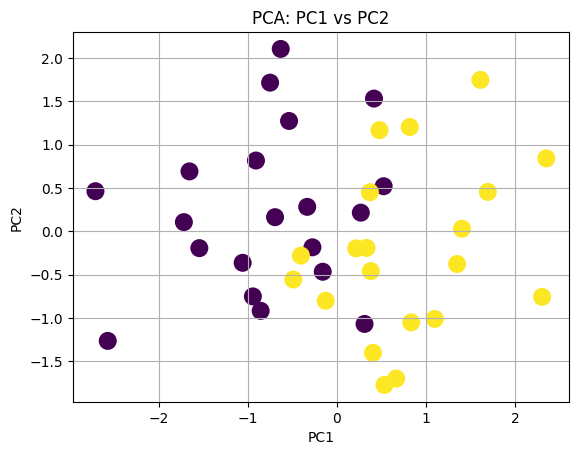

In [25]:
import matplotlib.pyplot as plt

new_df['target'] = new_df['target'].astype('str')

plt.scatter(
    new_df['PC1'],
    new_df['PC2'],
    c=new_df['target'].astype('category').cat.codes,
    s=120,
    linewidths=2
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.grid(True)
plt.show()